In [106]:
from pathlib import Path

import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.neighbors import NearestNeighbors

from plant_shape_analysis.dataloaders.trackplant3D import LeafSequencesDataset, PlantSequencesDataset
from plant_shape_analysis.data_preprocessing.detect_leaf_tips_trackplant3D import load_point_cloud_from_txt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


We now that the [TrackPlant3D dataset](https://github.com/entarot/TrackPlant3D-3D-organ-growth-tracking-framework-for-organ-level-dynamic-phenotyping/tree/main/data) contains point cloud plant sequences coming from the [4D plant registration](https://www.ipb.uni-bonn.de/data/4d-plant-registration/) dataset (which is an ealier unannotated but clean version of the Pheno4D dataset). All maize sequences from TrackPlant3D are derived from the 4D plant registration dataset, and the `tomato2` sequences also come from it.

## Trackplant3D dataset

In [2]:
dataset_path = Path("../data/TrackPlant3D")

### Leaf sequences dataset

We check how many sequences of leaves too have dense ground truth annotations.

In [3]:
leaf_dataset = LeafSequencesDataset(dataset_path, min_timepoints=3)
# leaf_dataset.get_leaf_timeseries_info()

In [93]:
maize_leaf_sequences = [f"{seq['sequence_name']}_leaf{seq["leaf_id"]}" for seq in leaf_dataset.get_timeseries_by_crop("maize")]
tomato_leaf_seq = [f"{seq['sequence_name']}_leaf{seq["leaf_id"]}" for seq in leaf_dataset.get_timeseries_by_crop("tomato2")]

In [94]:
print("Expected amount of leaf sequences with dense GT:")
len(maize_leaf_sequences) + len(tomato_leaf_seq)

Expected amount of leaf sequences with dense GT:


31

In [96]:
print("Expected amount of total leaf point clouds:")
sum([len(seq["timepoints"]) for seq in leaf_dataset.get_timeseries_by_crop("maize")]) + \
sum([len(seq["timepoints"]) for seq in leaf_dataset.get_timeseries_by_crop("tomato2")])

Expected amount of total leaf point clouds:


205

### Whole plant sequences dataset

In [9]:
plant_dataset = PlantSequencesDataset(dataset_path)

In [ ]:
def get_trackplant3D_scans_paths(crop: str) -> list[Path]:
    trackplant3D = []
    for name, path in sorted(plant_dataset.get_sequences_by_crop(crop).items(), key=lambda x: x[0]):
        trackplant3D.extend(path)
    return trackplant3D

In [65]:
maize_paths_trackplant3d = get_trackplant3D_scans_paths("maize")
tomato_paths_trackplant3d = get_trackplant3D_scans_paths("tomato2")
len(maize_paths_trackplant3d), len(tomato_paths_trackplant3d)

(26, 27)

## 4D plant registration dataset

In [76]:
base_path = Path("../data/4d_plant_registration_data")

In [77]:
def get_4dplantreg_scans_paths(base_path: Path) -> list[Path]:
    scans_list = []
    for plant in sorted(base_path.iterdir()):
        for seq in sorted(plant.iterdir()):
            scans_list.append(seq)
    return scans_list

In [78]:
maize_paths_4dplantreg = get_4dplantreg_scans_paths(base_path / "maize")
tomato_paths_4dplantreg = get_4dplantreg_scans_paths(base_path / "tomato")
len(maize_paths_4dplantreg), len(tomato_paths_4dplantreg)

(26, 27)

Check that we have the expected amount of plant scans on both datasets

In [80]:
assert len(maize_paths_4dplantreg) == len(maize_paths_trackplant3d)
assert len(tomato_paths_4dplantreg) == len(tomato_paths_trackplant3d)

There are 53 scans in total from 6 plant sequences, with a total of 31 leaf sequences and 205 leaf point clouds

Now we would like to align the scans of TrackPlant3D to their 4D plant registration dataset GT, and propagate the labels accordingly (e.g. via k-NN)

## Align scans across datasets

In [133]:
def load_trackplant3d_scan(path: Path):
    """Load a TrackPlant3D scan with labels"""
    data = load_point_cloud_from_txt(path)
    # Handle case where function returns tuple
    if isinstance(data, tuple):
        return data[0]  # Return just the points array
    return data

def load_4dplantreg_scan(path: Path):
    """Load a 4D plant registration scan (no labels)"""
    points = np.loadtxt(path, delimiter=' ')
    return points

def visualize_point_clouds_side_by_side(pc1, pc2, title1="TrackPlant3D", title2="4D Plant Registration"):
    """Visualize two point clouds side by side"""
    fig = plt.figure(figsize=(15, 6))
    
    # First point cloud
    ax1 = fig.add_subplot(121, projection='3d')
    if pc1.shape[1] >= 6:  # Has labels/colors
        ax1.scatter(pc1[:, 0], pc1[:, 1], pc1[:, 2], c=pc1[:, 3], s=1, alpha=0.6, cmap='viridis')
    else:
        ax1.scatter(pc1[:, 0], pc1[:, 1], pc1[:, 2], s=1, alpha=0.6)
    ax1.set_title(title1)
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    
    # Second point cloud
    ax2 = fig.add_subplot(122, projection='3d')
    ax2.scatter(pc2[:, 0], pc2[:, 1], pc2[:, 2], s=1, alpha=0.6, color='red')
    ax2.set_title(title2)
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    
    plt.tight_layout()
    plt.show()

def perform_icp_alignment(source_points, target_points, max_iterations=100, tolerance=1e-6):
    """
    Perform ICP alignment between source and target point clouds
    Returns: transformation matrix and aligned source points
    """
    # Create Open3D point clouds
    source_pcd = o3d.geometry.PointCloud()
    target_pcd = o3d.geometry.PointCloud()
    
    # Extract XYZ coordinates only
    source_xyz = source_points[:, :3] if source_points.shape[1] > 3 else source_points
    target_xyz = target_points[:, :3] if target_points.shape[1] > 3 else target_points
    
    source_pcd.points = o3d.utility.Vector3dVector(source_xyz)
    target_pcd.points = o3d.utility.Vector3dVector(target_xyz)
    
    # Set initial transformation (identity)
    init_transformation = np.eye(4)
    
    # Perform ICP
    reg_p2p = o3d.pipelines.registration.registration_icp(
        source_pcd, target_pcd, 
        max_correspondence_distance=0.1,  # Adjust based on your data scale
        init=init_transformation,
        estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPoint(),
        criteria=o3d.pipelines.registration.ICPConvergenceCriteria(
            max_iteration=max_iterations,
            relative_fitness=tolerance,
            relative_rmse=tolerance
        )
    )
    
    # Apply transformation to source points
    source_pcd.transform(reg_p2p.transformation)
    aligned_points = np.asarray(source_pcd.points)
    
    return reg_p2p.transformation, aligned_points, reg_p2p

def propagate_labels_knn(source_points_with_labels, target_points, k=3):
    """
    Propagate labels from source points to target points using k-NN
    
    Args:
        source_points_with_labels: Nx(3+) array where first 3 cols are XYZ, 
                                  remaining cols are labels/features
        target_points: Mx3 array with XYZ coordinates
        k: number of nearest neighbors to use
    
    Returns:
        target_points_with_labels: Mx(3+) array with propagated labels
    """
    # Extract coordinates and labels
    source_xyz = source_points_with_labels[:, :3]
    source_labels = source_points_with_labels[:, 3:]
    target_xyz = target_points[:, :3] if target_points.shape[1] > 3 else target_points
    
    # Fit k-NN model
    print(f"Fitting k-NN with k={k} on {len(source_xyz)} source points...")
    knn = NearestNeighbors(n_neighbors=k, algorithm='auto')
    knn.fit(source_xyz)
    
    # Find nearest neighbors for target points
    print(f"Finding nearest neighbors for {len(target_xyz)} target points...")
    distances, indices = knn.kneighbors(target_xyz)
    
    # Propagate labels (using weighted average based on inverse distance)
    propagated_labels = np.zeros((len(target_xyz), source_labels.shape[1]))
    
    for i in range(len(target_xyz)):
        # Get distances and indices for this point
        point_distances = distances[i]
        point_indices = indices[i]
        
        # Avoid division by zero for identical points
        point_distances = np.maximum(point_distances, 1e-8)
        
        # Calculate weights (inverse distance)
        weights = 1.0 / point_distances
        weights = weights / np.sum(weights)  # normalize
        
        # Weighted average of labels
        for j, idx in enumerate(point_indices):
            propagated_labels[i] += weights[j] * source_labels[idx]
    
    # Combine target coordinates with propagated labels
    target_with_labels = np.hstack([target_xyz, propagated_labels])
    
    return target_with_labels

def visualize_alignment_result(original_source, aligned_source, target, title="ICP Alignment Result"):
    """Visualize original, aligned, and target point clouds"""
    fig = plt.figure(figsize=(20, 6))
    
    # Original source
    ax1 = fig.add_subplot(131, projection='3d')
    source_xyz = original_source[:, :3] if original_source.shape[1] > 3 else original_source
    ax1.scatter(source_xyz[:, 0], source_xyz[:, 1], source_xyz[:, 2], 
               c='blue', s=1, alpha=0.6, label='Original Source')
    ax1.set_title('Original Source (TrackPlant3D)')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    
    # Aligned source
    ax2 = fig.add_subplot(132, projection='3d')
    ax2.scatter(aligned_source[:, 0], aligned_source[:, 1], aligned_source[:, 2], 
               c='green', s=1, alpha=0.6, label='Aligned Source')
    ax2.set_title('Aligned Source')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    
    # Overlay aligned source and target
    ax3 = fig.add_subplot(133, projection='3d')
    target_xyz = target[:, :3] if target.shape[1] > 3 else target
    ax3.scatter(target_xyz[:, 0], target_xyz[:, 1], target_xyz[:, 2], 
               c='red', s=1, alpha=0.4, label='Target (4D Plant Reg)')
    ax3.scatter(aligned_source[:, 0], aligned_source[:, 1], aligned_source[:, 2], 
               c='green', s=1, alpha=0.4, label='Aligned Source')
    ax3.set_title('Alignment Overlay')
    ax3.set_xlabel('X')
    ax3.set_ylabel('Y')
    ax3.set_zlabel('Z')
    ax3.legend()
    
    plt.tight_layout()
    plt.show()

def visualize_label_propagation(source_labeled, target_labeled, label_col=3):
    """Visualize the results of label propagation"""
    fig = plt.figure(figsize=(15, 6))
    
    # Source with original labels
    ax1 = fig.add_subplot(121, projection='3d')
    scatter1 = ax1.scatter(source_labeled[:, 0], source_labeled[:, 1], source_labeled[:, 2], 
                          c=source_labeled[:, label_col], s=1, alpha=0.6, cmap='viridis')
    ax1.set_title('Source: TrackPlant3D (Original Labels)')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    plt.colorbar(scatter1, ax=ax1, shrink=0.5)
    
    # Target with propagated labels
    ax2 = fig.add_subplot(122, projection='3d')
    scatter2 = ax2.scatter(target_labeled[:, 0], target_labeled[:, 1], target_labeled[:, 2], 
                          c=target_labeled[:, label_col], s=1, alpha=0.6, cmap='viridis')
    ax2.set_title('Target: 4D Plant Registration (Propagated Labels)')
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_zlabel('Z')
    plt.colorbar(scatter2, ax=ax2, shrink=0.5)
    
    plt.tight_layout()
    plt.show()

TrackPlant3D scan shape: (10000, 3)
4D Plant Registration scan shape: (346936, 3)
TrackPlant3D path: ../data/TrackPlant3D/gt_corrected_v1/maize/21_maize_control_plant3_D02.txt
4D Plant Registration path: ../data/4d_plant_registration_data/maize/plant3/03-15.txt


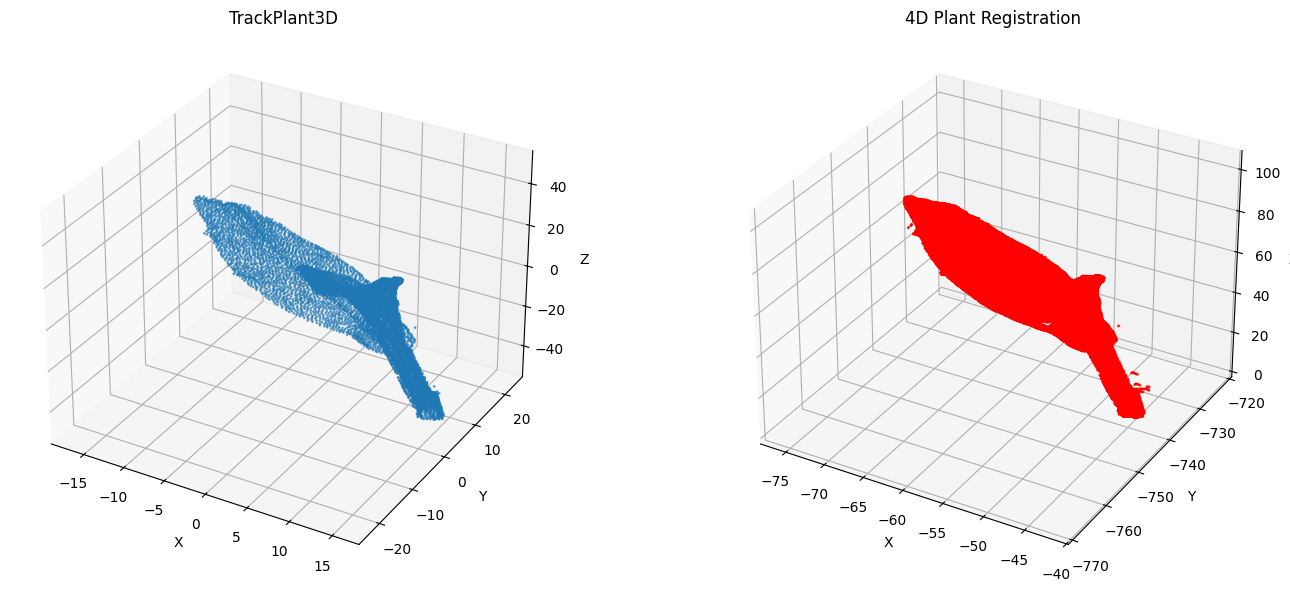

In [134]:
scan = 20
trackplant3d_scan = load_trackplant3d_scan(maize_paths_trackplant3d[scan])
plantreg_scan = load_4dplantreg_scan(maize_paths_4dplantreg[scan])

print(f"TrackPlant3D scan shape: {trackplant3d_scan.shape}")
print(f"4D Plant Registration scan shape: {plantreg_scan.shape}")
print(f"TrackPlant3D path: {maize_paths_trackplant3d[scan]}")
print(f"4D Plant Registration path: {maize_paths_4dplantreg[scan]}")

visualize_point_clouds_side_by_side(trackplant3d_scan, plantreg_scan)

In [135]:
# Simple alignment and interactive viewer
def interactive_alignment_viewer(trackplant3d_scan, plantreg_scan, aligned_plantreg=None):
    """Interactive Open3D viewer for alignment inspection"""
    # Create point clouds
    tp3d_pcd = o3d.geometry.PointCloud()
    pr_pcd = o3d.geometry.PointCloud()
    
    # Set coordinates
    tp3d_xyz = trackplant3d_scan[:, :3] if trackplant3d_scan.shape[1] > 3 else trackplant3d_scan
    pr_xyz = plantreg_scan[:, :3] if plantreg_scan.shape[1] > 3 else plantreg_scan
    
    tp3d_pcd.points = o3d.utility.Vector3dVector(tp3d_xyz)
    pr_pcd.points = o3d.utility.Vector3dVector(pr_xyz)
    
    # Color the point clouds differently
    tp3d_pcd.paint_uniform_color([0, 0, 1])  # Blue for TrackPlant3D
    pr_pcd.paint_uniform_color([1, 0, 0])    # Red for 4D Plant Registration
    
    # If we have aligned version, add it too
    geometries = [tp3d_pcd, pr_pcd]
    if aligned_plantreg is not None:
        aligned_pcd = o3d.geometry.PointCloud()
        aligned_xyz = aligned_plantreg[:, :3] if aligned_plantreg.shape[1] > 3 else aligned_plantreg
        aligned_pcd.points = o3d.utility.Vector3dVector(aligned_xyz)
        aligned_pcd.paint_uniform_color([0, 1, 0])  # Green for aligned
        geometries.append(aligned_pcd)
    
    print("Interactive viewer controls:")
    print("- Mouse: Rotate view")
    print("- Scroll: Zoom in/out") 
    print("- Ctrl+Mouse: Pan")
    print("- Blue: TrackPlant3D (sparse, with labels)")
    print("- Red: Original 4D Plant Registration (dense)")
    if aligned_plantreg is not None:
        print("- Green: Aligned 4D Plant Registration")
    print("- Close window when done inspecting")
    
    # Launch interactive viewer
    o3d.visualization.draw_geometries(
        geometries,
        window_name="Point Cloud Alignment Viewer",
        width=1200,
        height=800
    )

def simple_align_plantreg_to_trackplant3d(trackplant3d_scan, plantreg_scan):
    """Simple centroid-based alignment"""
    tp3d_xyz = trackplant3d_scan[:, :3] if trackplant3d_scan.shape[1] > 3 else trackplant3d_scan
    pr_xyz = plantreg_scan[:, :3] if plantreg_scan.shape[1] > 3 else plantreg_scan
    
    # Compute centroids
    centroid_tp3d = np.mean(tp3d_xyz, axis=0)
    centroid_pr = np.mean(pr_xyz, axis=0)
    
    # Translation to align 4D plant reg to TrackPlant3D coordinates
    translation = centroid_tp3d - centroid_pr
    
    # Apply translation
    aligned_pr = plantreg_scan.copy()
    aligned_pr[:, :3] += translation
    
    print(f"Applied translation: {translation}")
    print(f"Translation magnitude: {np.linalg.norm(translation):.6f}")
    
    return aligned_pr, translation

# Perform simple alignment
print("=== SIMPLE CENTROID ALIGNMENT ===")
aligned_plantreg, translation_applied = simple_align_plantreg_to_trackplant3d(trackplant3d_scan, plantreg_scan)

# Launch interactive Open3D viewer to inspect alignment
print("\nLaunching interactive Open3D viewer...")
print("You can inspect the alignment quality interactively!")

interactive_alignment_viewer(trackplant3d_scan, plantreg_scan, aligned_plantreg)

=== SIMPLE CENTROID ALIGNMENT ===
Applied translation: [ 59.75413854 746.21341529 -59.19085635]
Translation magnitude: 750.938463

Launching interactive Open3D viewer...
You can inspect the alignment quality interactively!
Interactive viewer controls:
- Mouse: Rotate view
- Scroll: Zoom in/out
- Ctrl+Mouse: Pan
- Blue: TrackPlant3D (sparse, with labels)
- Red: Original 4D Plant Registration (dense)
- Green: Aligned 4D Plant Registration
- Close window when done inspecting


=== ALIGNMENT ANALYSIS ===
TrackPlant3D centroid: [6.22234764 0.93975897 3.01582074]
4D Plant Reg centroid: [ -53.53179089 -745.27365632   62.20667709]
Translation to align 4D Plant Reg to TrackPlant3D: [ 59.75413854 746.21341529 -59.19085635]
Translation magnitude: 750.938463

TrackPlant3D bounding box: [-16.745501 -22.693399 -48.686283] to [15.7218   22.663799 48.665684]
4D Plant Reg bounding box: [ -75.8537 -767.9232    4.4001] to [ -42.2247 -722.5364  101.8977]

Size ratio (4D/TrackPlant3D): [1.03578058 1.00065264 1.00149594]

=== TRANSLATING 4D PLANT REG TO TRACKPLANT3D COORDINATES ===

=== APPLYING ICP FOR FINE ALIGNMENT ===
Applied translation: [-1.89182003e-13  3.85891319e-12 -1.11421983e-12]
Translation magnitude: 0.000000
ICP fitness: 0.004589
ICP RMSE: 0.076079


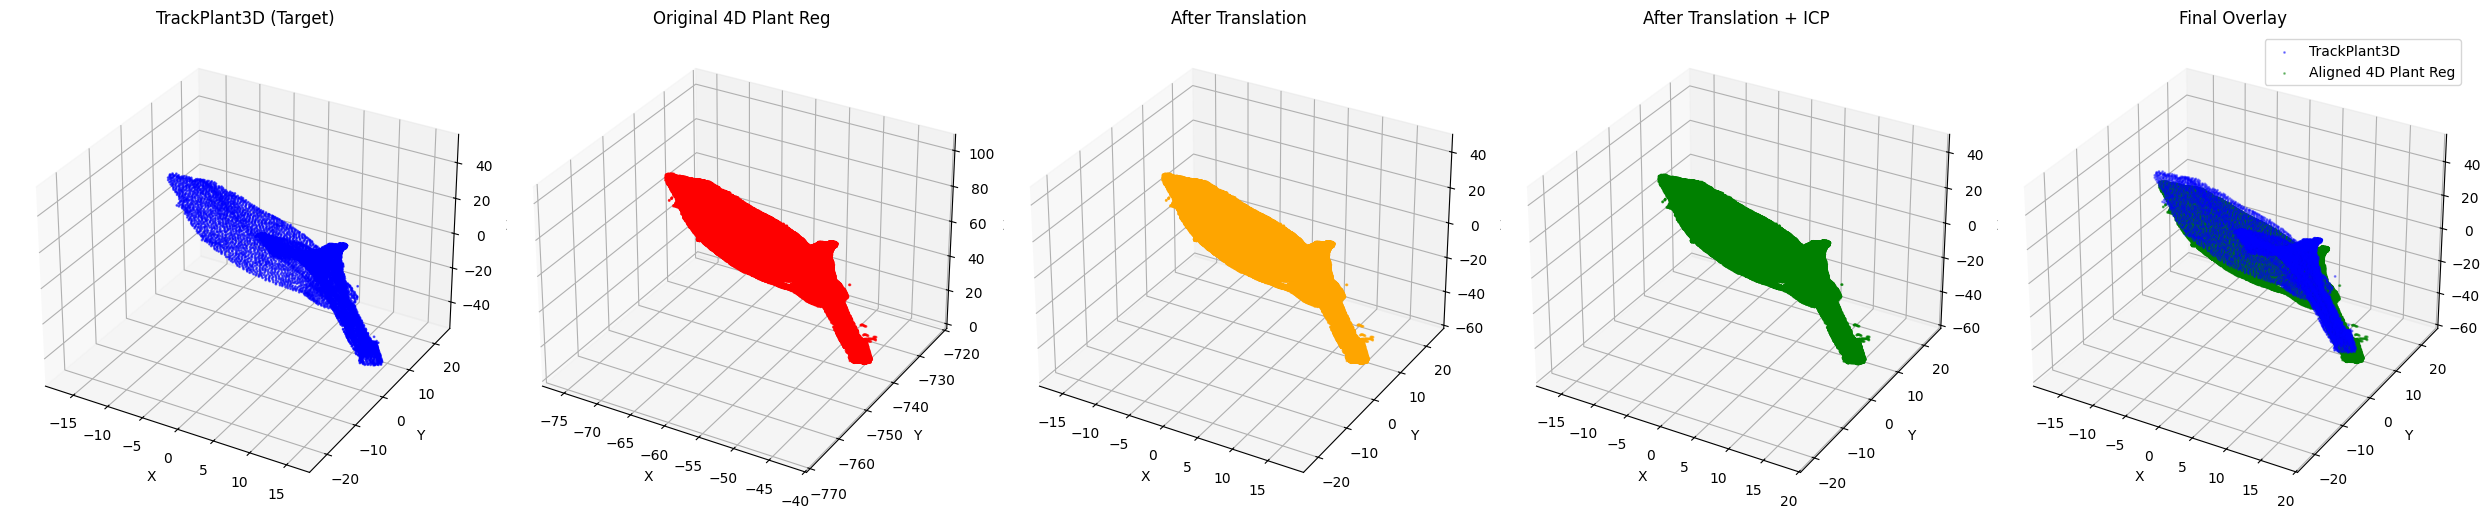


Final alignment quality:
ICP fitness: 0.004589
ICP RMSE: 0.076079


In [ ]:
# Let's analyze the point clouds and then align 4D plant reg to TrackPlant3D coordinates
def analyze_alignment_need(pc1, pc2, name1="TrackPlant3D", name2="4D Plant Reg"):
    """Analyze what kind of alignment is needed between two point clouds"""
    xyz1 = pc1[:, :3] if pc1.shape[1] > 3 else pc1
    xyz2 = pc2[:, :3] if pc2.shape[1] > 3 else pc2
    
    # Compute centroids
    centroid1 = np.mean(xyz1, axis=0)
    centroid2 = np.mean(xyz2, axis=0)
    
    # Compute bounding boxes
    min1, max1 = np.min(xyz1, axis=0), np.max(xyz1, axis=0)
    min2, max2 = np.min(xyz2, axis=0), np.max(xyz2, axis=0)
    
    # Translation to move pc2 to pc1's coordinate system
    translation = centroid1 - centroid2
    
    print(f"{name1} centroid: {centroid1}")
    print(f"{name2} centroid: {centroid2}")
    print(f"Translation to align {name2} to {name1}: {translation}")
    print(f"Translation magnitude: {np.linalg.norm(translation):.6f}")
    
    print(f"\n{name1} bounding box: {min1} to {max1}")
    print(f"{name2} bounding box: {min2} to {max2}")
    
    # Check if they're roughly the same size
    size1 = max1 - min1
    size2 = max2 - min2
    size_ratio = size2 / (size1 + 1e-8)
    print(f"\nSize ratio (4D/TrackPlant3D): {size_ratio}")
    
    return translation, centroid1, centroid2

def translate_point_cloud(points, translation):
    """Apply translation to a point cloud"""
    aligned = points.copy()
    aligned[:, :3] += translation
    return aligned

def align_with_translation_and_icp(source_points, target_points, max_iterations=50):
    """
    First apply translation, then fine-tune with ICP
    Returns: final transformation matrix, aligned points, and ICP result
    """
    # Step 1: Compute translation to align centroids
    source_xyz = source_points[:, :3] if source_points.shape[1] > 3 else source_points
    target_xyz = target_points[:, :3] if target_points.shape[1] > 3 else target_points
    
    source_centroid = np.mean(source_xyz, axis=0)
    target_centroid = np.mean(target_xyz, axis=0)
    translation = target_centroid - source_centroid
    
    # Apply translation
    translated_source = translate_point_cloud(source_points, translation)
    
    print(f"Applied translation: {translation}")
    print(f"Translation magnitude: {np.linalg.norm(translation):.6f}")
    
    # Step 2: Apply ICP for fine alignment
    transformation_matrix, icp_aligned, icp_result = perform_icp_alignment(
        translated_source, target_points, max_iterations=max_iterations
    )
    
    print(f"ICP fitness: {icp_result.fitness:.6f}")
    print(f"ICP RMSE: {icp_result.inlier_rmse:.6f}")
    
    return transformation_matrix, icp_aligned, icp_result, translation

# Analyze what alignment is needed
print("=== ALIGNMENT ANALYSIS ===")
translation, cent_tp3d, cent_4dpr = analyze_alignment_need(trackplant3d_scan, plantreg_scan)

# Apply translation to 4D plant registration to move it to TrackPlant3D coordinates
print("\n=== TRANSLATING 4D PLANT REG TO TRACKPLANT3D COORDINATES ===")
translated_plantreg = translate_point_cloud(plantreg_scan, translation)

# Now apply ICP for fine alignment
print("\n=== APPLYING ICP FOR FINE ALIGNMENT ===")
transformation_matrix, final_aligned_plantreg, icp_result, initial_translation = align_with_translation_and_icp(
    translated_plantreg, trackplant3d_scan, max_iterations=100
)

# Visualize the alignment process
fig = plt.figure(figsize=(25, 5))

ax1 = fig.add_subplot(151, projection='3d')
ax1.scatter(trackplant3d_scan[:, 0], trackplant3d_scan[:, 1], trackplant3d_scan[:, 2], 
           c='blue', s=1, alpha=0.6)
ax1.set_title('TrackPlant3D (Target)')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')

ax2 = fig.add_subplot(152, projection='3d')
ax2.scatter(plantreg_scan[:, 0], plantreg_scan[:, 1], plantreg_scan[:, 2], 
           c='red', s=1, alpha=0.6)
ax2.set_title('Original 4D Plant Reg')
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')

ax3 = fig.add_subplot(153, projection='3d')
ax3.scatter(translated_plantreg[:, 0], translated_plantreg[:, 1], translated_plantreg[:, 2], 
           c='orange', s=1, alpha=0.6)
ax3.set_title('After Translation')
ax3.set_xlabel('X'); ax3.set_ylabel('Y'); ax3.set_zlabel('Z')

ax4 = fig.add_subplot(154, projection='3d')
ax4.scatter(final_aligned_plantreg[:, 0], final_aligned_plantreg[:, 1], final_aligned_plantreg[:, 2], 
           c='green', s=1, alpha=0.6)
ax4.set_title('After Translation + ICP')
ax4.set_xlabel('X'); ax4.set_ylabel('Y'); ax4.set_zlabel('Z')

ax5 = fig.add_subplot(155, projection='3d')
ax5.scatter(trackplant3d_scan[:, 0], trackplant3d_scan[:, 1], trackplant3d_scan[:, 2], 
           c='blue', s=1, alpha=0.4, label='TrackPlant3D')
ax5.scatter(final_aligned_plantreg[:, 0], final_aligned_plantreg[:, 1], final_aligned_plantreg[:, 2], 
           c='green', s=1, alpha=0.4, label='Aligned 4D Plant Reg')
ax5.set_title('Final Overlay')
ax5.set_xlabel('X'); ax5.set_ylabel('Y'); ax5.set_zlabel('Z')
ax5.legend()

plt.tight_layout()
plt.show()

print(f"\nFinal alignment quality:")
print(f"ICP fitness: {icp_result.fitness:.6f}")
print(f"ICP RMSE: {icp_result.inlier_rmse:.6f}")

In [ ]:
# Now propagate labels from TrackPlant3D to the aligned 4D plant registration scan
print("=== LABEL PROPAGATION ===")
print(f"TrackPlant3D (source with labels) shape: {trackplant3d_scan.shape}")
print(f"Aligned 4D Plant Reg (target) shape: {final_aligned_plantreg.shape}")

# Propagate labels from TrackPlant3D to the aligned 4D plant registration scan
print("\nPropagating labels using k-NN...")
aligned_plantreg_with_labels = propagate_labels_knn(trackplant3d_scan, final_aligned_plantreg, k=5)

print(f"Aligned 4D Plant Reg with labels shape: {aligned_plantreg_with_labels.shape}")

# Visualize the label propagation results
visualize_label_propagation(trackplant3d_scan, aligned_plantreg_with_labels)

# Show statistics about the label propagation
print("\n=== LABEL PROPAGATION STATISTICS ===")
if trackplant3d_scan.shape[1] > 3 and aligned_plantreg_with_labels.shape[1] > 3:
    original_labels = trackplant3d_scan[:, 3]
    propagated_labels = aligned_plantreg_with_labels[:, 3]
    
    print(f"Original labels range: {np.min(original_labels):.3f} to {np.max(original_labels):.3f}")
    print(f"Propagated labels range: {np.min(propagated_labels):.3f} to {np.max(propagated_labels):.3f}")
    print(f"Original unique labels: {len(np.unique(original_labels))}")
    print(f"Propagated unique labels (continuous): {len(np.unique(np.round(propagated_labels, 1)))}")
    print(f"Mean label - Original: {np.mean(original_labels):.3f}, Propagated: {np.mean(propagated_labels):.3f}")
    
    # Show label distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.hist(original_labels, bins=50, alpha=0.7, label='Original (TrackPlant3D)')
    ax1.set_xlabel('Label Value')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Original Label Distribution')
    ax1.legend()
    
    ax2.hist(propagated_labels, bins=50, alpha=0.7, color='orange', label='Propagated (4D Plant Reg)')
    ax2.set_xlabel('Label Value') 
    ax2.set_ylabel('Frequency')
    ax2.set_title('Propagated Label Distribution')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

# Store the final result for potential saving
final_result = {
    'trackplant3d_original': trackplant3d_scan,
    'plantreg_original': plantreg_scan,
    'plantreg_aligned': final_aligned_plantreg,
    'plantreg_with_labels': aligned_plantreg_with_labels,
    'translation': translation,
    'transformation_matrix': transformation_matrix,
    'icp_fitness': icp_result.fitness,
    'icp_rmse': icp_result.inlier_rmse
}

print(f"\nAlignment pipeline completed successfully!")
print(f"Final ICP fitness: {icp_result.fitness:.6f}")
print(f"Final ICP RMSE: {icp_result.inlier_rmse:.6f}")
print(f"Dense point cloud now has {aligned_plantreg_with_labels.shape[0]} points with propagated labels")

In [ ]:
def process_all_pairs(trackplant3d_paths, plantreg_paths, output_dir=None, save_results=False):
    """
    Process all corresponding pairs of scans
    
    Args:
        trackplant3d_paths: List of paths to TrackPlant3D scans
        plantreg_paths: List of paths to 4D plant registration scans
        output_dir: Directory to save results (if save_results=True)
        save_results: Whether to save the labeled point clouds
    
    Returns:
        results: List of dictionaries containing alignment and propagation results
    """
    assert len(trackplant3d_paths) == len(plantreg_paths), "Number of paths must match"
    
    results = []
    
    for i, (tp3d_path, pr_path) in enumerate(zip(trackplant3d_paths, plantreg_paths)):
        print(f"\nProcessing pair {i+1}/{len(trackplant3d_paths)}")
        print(f"TrackPlant3D: {tp3d_path.name}")
        print(f"4D Plant Reg: {pr_path.name}")
        
        try:
            # Load scans
            tp3d_scan = load_trackplant3d_scan(tp3d_path)
            pr_scan = load_4dplantreg_scan(pr_path)
            
            # Perform ICP alignment
            transformation, aligned_tp3d_xyz, icp_result = perform_icp_alignment(
                tp3d_scan, pr_scan, max_iterations=50
            )
            
            # Apply transformation to full TrackPlant3D scan
            aligned_tp3d_full = tp3d_scan.copy()
            aligned_tp3d_full[:, :3] = aligned_tp3d_xyz
            
            # Propagate labels
            pr_with_labels = propagate_labels_knn(aligned_tp3d_full, pr_scan, k=5)
            
            # Store results
            result = {
                'trackplant3d_path': tp3d_path,
                'plantreg_path': pr_path,
                'transformation_matrix': transformation,
                'icp_fitness': icp_result.fitness,
                'icp_rmse': icp_result.inlier_rmse,
                'original_tp3d': tp3d_scan,
                'aligned_tp3d': aligned_tp3d_full,
                'plantreg_with_labels': pr_with_labels
            }
            
            results.append(result)
            
            print(f"✓ Fitness: {icp_result.fitness:.4f}, RMSE: {icp_result.inlier_rmse:.4f}")
            
            # Save if requested
            if save_results and output_dir:
                output_path = Path(output_dir)
                output_path.mkdir(exist_ok=True, parents=True)
                
                # Save aligned TrackPlant3D
                aligned_file = output_path / f"{tp3d_path.stem}_aligned.txt"
                np.savetxt(aligned_file, aligned_tp3d_full, fmt='%.6f')
                
                # Save 4D plant registration with propagated labels
                labeled_file = output_path / f"{pr_path.stem}_labeled.txt"
                np.savetxt(labeled_file, pr_with_labels, fmt='%.6f')
                
                print(f"✓ Saved results to {output_path}")
                
        except Exception as e:
            print(f"✗ Error processing pair {i+1}: {e}")
            continue
    
    return results

# Example: Process first 3 pairs to test
print("Processing first 3 maize pairs as a test...")
test_results = process_all_pairs(
    maize_paths_trackplant3d[:3], 
    maize_paths_4dplantreg[:3], 
    save_results=False
)

print(f"\nProcessed {len(test_results)} pairs successfully")
for i, result in enumerate(test_results):
    print(f"Pair {i+1}: Fitness={result['icp_fitness']:.4f}, RMSE={result['icp_rmse']:.4f}")